In [61]:
# We can use Interrupt, to validate and authenticate if a user can ask this question and get response
# For example, if a user asks question about someone else, then we intrrupt the graph and validate if 
# they have the access to that data, if so then resume from there, if not send other response and close
# graph

In [3]:
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader

from langgraph.graph import END, StateGraph, START, MessagesState
from langchain_core.prompts import ChatPromptTemplate
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage, RemoveMessage, trim_messages
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field

from typing import List
from typing_extensions import TypedDict
import uuid

from IPython.display import Image, display

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

endpoint = os.getenv("AZURE_OPENAI_SERVICE")
model_name = os.getenv("MODEL_DEPLOYMENT_NAME")
deployment = os.getenv("MODEL_DEPLOYMENT_NAME")
subscription_key = os.getenv("AZURE_OPENAI_CHATGPT_DEPLOYMENT")
api_version = "2024-12-01-preview"


llm_client = AzureChatOpenAI(
    api_version=api_version,
    azure_endpoint=endpoint,
    api_key=subscription_key,
    deployment_name=deployment,
    max_tokens=1500
)


llm_with_tools = llm_client.bind_tools(tools)

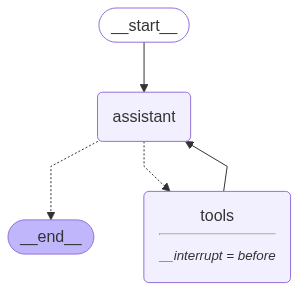

In [8]:
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}


builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
# interrupt_after actually means interrupt after a node and all its outgoing edges run
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [9]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

thread = uuid.uuid4()
config = {"configurable": {"thread_id": thread}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, config=config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_fvx3l31UzBt3IT56keuK1mmn)
 Call ID: call_fvx3l31UzBt3IT56keuK1mmn
  Args:
    a: 2
    b: 3


In [10]:
# Notice, the graph stopped before the actual tool call, here the LLM provides output that a tool
# call is required with these args, but the actual tool call is not made.

In [11]:
state = graph.get_state(config)
state.next

('tools',)

In [13]:
# keeping the input as none because the state already holds the message with AIMessage to tool_calls
for event in graph.stream(None, config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (call_fvx3l31UzBt3IT56keuK1mmn)
 Call ID: call_fvx3l31UzBt3IT56keuK1mmn
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [14]:
# With the interrupt we can add user control with basic logic

initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = uuid.uuid4()
config = {"configurable": {"thread_id": thread}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, config, stream_mode="values"):
    event['messages'][-1].pretty_print()

# Get user feedback
user_approval = input("Do you want to call the tool? (yes/no): ")

# Check approval
if user_approval.lower() == "yes":
    
    # If approved, continue the graph execution
    for event in graph.stream(None, config, stream_mode="values"):
        event['messages'][-1].pretty_print()
        
else:
    print("Operation cancelled by user.")

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_H4eyKdbeYykCRiAmgA52CMk9)
 Call ID: call_H4eyKdbeYykCRiAmgA52CMk9
  Args:
    a: 2
    b: 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_H4eyKdbeYykCRiAmgA52CMk9)
 Call ID: call_H4eyKdbeYykCRiAmgA52CMk9
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [20]:
# We can stream the state data through stream and astream method for graph object.
# stream -> ["update", "values"], update only streams the next new state value
# But if I want to stream content of the response, we will have to use stream_events

thread = uuid.uuid4()
config = {"configurable": {"thread_id": thread}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    # print(event)
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == 'assistant':
        data = event["data"]
        print(data["chunk"].content, end="")

The San Francisco 49ers are a professional football team based in San Francisco, California. They are part of the National Football League (NFL) and compete in the league's National Football Conference (NFC) West division. Here are some key details about the 49ers:

### History
- **Founded**: 1946
- **NFL Entry**: 1950
- Named after the prospectors who arrived in Northern California during the 1849 Gold Rush, the team has deep ties to the Bay Area's history.

### Achievements
- **Super Bowl Wins**: The 49ers have won 5 Super Bowls (1981, 1984, 1988, 1989, 1994).
- **Conference Championships**: Numerous NFC titles throughout their history.
- **Hall of Fame Players**: Includes legends such as Joe Montana, Steve Young, Jerry Rice, and Ronnie Lott.

### Stadium
- The team plays its home games at **Levi's Stadium**, located in Santa Clara, California. Previously, they played at Candlestick Park in San Francisco.

### Team Identity
- **Colors**: Red and gold
- **Mascot**: Sourdough Sam

### 

In [23]:
# We see implementation of breakpoints - but they can be setup manually or dynamically
# either use interrupt_before/after or use NodeInterrupt internally in the code logic

# (1) you can do it conditionally (from inside a node based on developer-defined logic).

# (2) you can communicate to the user why its interrupted (by passing whatever you want to the NodeInterrupt).

In [37]:
# Interrupt method has changed since the doc was written for langgraph, we need to build our own node 
from langgraph.types import interrupt, Command

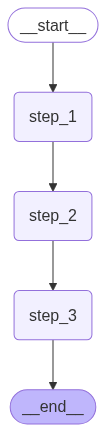

In [45]:
class State(TypedDict):
    input: str

def step_1(state: State) -> State:
    print("---Step 1---")
    return state

def step_2(state: State) -> State:
    # Let's optionally raise a NodeInterrupt if the length of the input is longer than 5 characters
    if len(state['input']) > 5:
        user_input = interrupt(f"Received input that is longer than 5 characters: {state['input']}")
        print(f"User provided a string with lenght less than 5 (I hope): {user_input}")
        state['input'] = state['input'][:5]
        return state
    
    print("---Step 2---")
    return state

def step_3(state: State) -> State:
    print("---Step 3---")
    return state

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = MemorySaver()

# Compile the graph with memory
graph = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [56]:
initial_input = {"input": "hello world"}
thread = uuid.uuid4()
thread_config = {"configurable": {"thread_id": thread}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread_config, stream_mode="values"):
    print(event)

{'input': 'hello world'}
---Step 1---
{'input': 'hello world'}


In [57]:
# We passed step 1/ node 1
graph.get_state(thread_config)

StateSnapshot(values={'input': 'hello world'}, next=('step_2',), config={'configurable': {'thread_id': '0d765625-6bb1-4b0e-9563-079e75e4f074', 'checkpoint_ns': '', 'checkpoint_id': '1f077bc3-833a-61c2-8001-29e2657c1629'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-08-12T20:37:52.895007+00:00', parent_config={'configurable': {'thread_id': '0d765625-6bb1-4b0e-9563-079e75e4f074', 'checkpoint_ns': '', 'checkpoint_id': '1f077bc3-8337-6c6a-8000-c674bd04f884'}}, tasks=(PregelTask(id='f12e019c-be0e-2d08-cb60-b8c1267bd376', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(Interrupt(value='Received input that is longer than 5 characters: hello world', id='88fef2b56662ac67349511d6302de757'),), state=None, result=None),), interrupts=(Interrupt(value='Received input that is longer than 5 characters: hello world', id='88fef2b56662ac67349511d6302de757'),))

In [58]:
# Interrupted at node 2
graph.invoke(None, thread_config)

{'input': 'hello world',
 '__interrupt__': [Interrupt(value='Received input that is longer than 5 characters: hello world', id='88fef2b56662ac67349511d6302de757')]}

In [ ]:
# Provided input at node 2 and Passing throught the rest of the children nodes
for event in graph.stream(Command(resume="Sike I didnt provide a string with less than 5 length lol"), thread_config):
    print(event)

User provided a string with lenght less than 5 (I hope): Sike I didnt provide a string with less than 5 length lol
{'step_2': {'input': 'hello'}}
---Step 3---
{'step_3': {'input': 'hello'}}


In [ ]:
# You can also use .update_state() to directly change the state before going to next node
graph.update_state(
    config,
    {"messages": [HumanMessage(content="No, actually multiply 3 and 3!")]},
    # as_node="name_of_node"
)

{'configurable': {'thread_id': 'c1b0574a-326c-4641-bb7d-f8e58b59f3b0',
  'checkpoint_ns': '',
  'checkpoint_id': '1f077bce-6add-6420-8000-b395577bd522'}}